# Mortalidad Evitable en Argentina, 2005–2024
## Análisis de defunciones evitables mediante atención médica oportuna y efectiva

**Fuentes:** DEIS — Ministerio de Salud de la Nación Argentina | INDEC — Proyecciones provinciales de población
**Metodología:** Nolte & McKee (2003) · Estandarización directa por edad (OMS 2001) · Regresión binomial negativa
**Período:** 2005–2024 · **Escala:** tasa por 100.000 habitantes estandarizada por edad

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

ROOT = Path("..").resolve()
TABLES = ROOT / "output" / "tables"

# Paleta institucional
C_MALE   = "#2166ac"
C_FEMALE = "#d6604d"
C_BOTH   = "#1a1a2e"
C_COVID  = "#e07b39"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Cargar tablas
nat   = pd.read_csv(TABLES / "national_series.csv")
prov  = pd.read_csv(TABLES / "tasa_evitable_provincia_anio_sexo.csv")
cause = pd.read_csv(TABLES / "evitable_by_cause.csv")
age   = pd.read_csv(TABLES / "evitable_by_agegroup.csv")
cv    = pd.read_csv(TABLES / "cv_by_year.csv")
trend = pd.read_csv(TABLES / "trend_by_province.csv")

# Mapa de provincias
PROV_NAMES = {
     2: "CABA",          6: "Buenos Aires",  10: "Catamarca",
    14: "Córdoba",      18: "Corrientes",    22: "Chaco",
    26: "Chubut",       30: "Entre Ríos",    34: "Formosa",
    38: "Jujuy",        42: "La Pampa",      46: "La Rioja",
    50: "Mendoza",      54: "Misiones",      58: "Neuquén",
    62: "Río Negro",    66: "Salta",         70: "San Juan",
    74: "San Luis",     78: "Santa Cruz",    82: "Santa Fe",
    86: "Santiago del Estero", 90: "Tucumán", 94: "Tierra del Fuego",
}
prov["PROV_NOMBRE"] = prov["PROVRES"].map(PROV_NAMES).fillna(prov["PROVRES"].astype(str))
if "PROV_NOMBRE" not in trend.columns:
    trend["PROV_NOMBRE"] = trend["PROVRES"].map(PROV_NAMES).fillna(trend["PROVRES"].astype(str))

print("Tablas cargadas.")
print(f"  Años: {nat['ANIO'].min()}–{nat['ANIO'].max()}")
print(f"  Provincias: {prov['PROVRES'].nunique()}")

Tablas cargadas.
  Años: 2005–2024
  Provincias: 24


---
## Resumen / Abstract

**Contexto:** La mortalidad evitable (ME) —defunciones por causas que una atención médica oportuna y efectiva podría haber evitado— es un indicador sensible de la calidad del sistema de salud. Argentina carece de una serie temporal provincial actualizada y reproducible.

**Objetivo:** Estimar y analizar la evolución de la ME en las 24 jurisdicciones argentinas entre 2005 y 2024, desagregada por sexo y grupo etario.

**Métodos:** Se clasificaron las defunciones del registro de hechos vitales del DEIS según la lista de Nolte & McKee (2003, 36 grupos de causas, 429 códigos CIE-10 a 3 caracteres). Se calcularon tasas brutas y tasas estandarizadas directamente por edad usando la Población Mundial Estándar OMS (2000–2025). Los intervalos de confianza al 95% se obtuvieron con la aproximación de Byar (Breslow & Day 1987). La tendencia temporal se modeló con regresión binomial negativa por provincia.

**Resultados principales:** La tasa nacional pasó de ≈106/100k (2005) a ≈104/100k (2024), con un pico en 2016 (~110/100k) y un mínimo transitorio en 2020 (COVID-19 distorsionó la clasificación de causas). La brecha entre varones y mujeres se mantuvo estable (varones ≈35–40% más alta). La heterogeneidad interprovincial es sustancial: en el último año disponible la tasa máxima triplicó a la mínima. Las causas cardiovasculares (cerebrovascular + cardiopatía isquémica) concentran el 27% de la ME.

**Conclusión:** La ME muestra una leve tendencia decreciente a nivel nacional, pero con alta inequidad territorial que persiste a lo largo de todo el período analizado.

---
## 1. Introducción

El concepto de **mortalidad evitable** fue propuesto por Rutstein et al. (1976) y operacionalizado para comparaciones internacionales por Nolte & McKee (2003). Identifica causas de muerte para las cuales existe evidencia de que un sistema de salud que funcione adecuadamente —con acceso oportuno, cobertura universal y calidad en la atención— podría evitar o posponer significativamente la muerte.

A diferencia de indicadores de proceso (tasas de consulta, cobertura vacunal), la ME mide resultados finales en salud y es sensible a desigualdades en el acceso y la calidad de la atención. Por eso ha sido adoptada como indicador de desempeño en la Unión Europea (EURO-STAT), la OCDE y organismos de salud de América Latina.

**En Argentina**, el registro de defunciones del DEIS (Dirección de Estadísticas e Información de Salud) cubre los 24 distritos con codificación CIE-10 desde 1997. Sin embargo, los análisis publicados son escasos, no siempre reproducibles y raramente cubren el período post-pandemia. Este trabajo construye una serie 2005–2024 con metodología explícita y código abierto.

### 1.1 Objetivos específicos

1. Construir una serie temporal de tasas de ME estandarizadas por edad, desagregada por provincia, año y sexo.
2. Identificar las causas y grupos etarios de mayor contribución a la carga evitable.
3. Estimar la tendencia temporal provincial y cuantificar la inequidad interprovincial.
4. Analizar el impacto de los años COVID-19 (2020–2021) sobre la clasificación de ME.

---
## 2. Métodos

### 2.1 Fuentes de datos

| Fuente | Descripción | Período |
|--------|-------------|---------|
| DEIS — defweb05.csv … defweb24.csv | Registro de defunciones: CAUSA (CIE-10), PROVRES, SEXO, GRUPEDAD, CUENTA | 2005–2024 |
| INDEC c2_proyecciones_prov_2010_2040.xls | Población por provincia × sexo × quinquenio (base 2010) | 2005–2021* |
| INDEC proyecciones_jurisdicciones_2022_2040_base.csv | Ídem, base 2022 | 2022–2024 |

*Los años 2005–2009 usan el valor de 2010 como aproximación (la proyección no retrocede antes de 2010).

### 2.2 Causas evitables

Se utilizó la lista de **Nolte & McKee (2003)** (*amenable mortality* / mortalidad evitable), que comprende 36 grupos etiológicos (429 códigos CIE-10 a 3 caracteres) con restricciones de edad y, en algunos casos, sexo. La cardiopatía isquémica (I20–I25) se incluye al **50%** de los conteos, siguiendo la convención original que reconoce que parte de la mortalidad isquémica no es evitable con la atención médica disponible.

Ajustes respecto a la lista original publicada:

| Causa | Corrección |
|-------|-----------|
| Ca. piel | C44 (no melanoma) en lugar de C43 (melanoma) |
| Úlcera péptica | K25–K27 (excluido K28 — úlcera gastro-yeyunal, poco evitable) |
| Nefritis y nefrosis | N00–N07 + N17–N19 + N25–N27 (discontinuo) |
| Hipertensión | I10–I13 + I15 (hipertensión secundaria incluida) |
| Ca. cuerpo uterino | C54+C55, restringido a 0–44 años |
| Sarampión | Restringido a 1–14 años |
| Secuelas de TBC | B90 incluido junto con A15–A19 |

### 2.3 Clasificación y agregación

Se realizó un join entre el registro de defunciones y la tabla de causas evitables por código CIE-10 truncado a 3 caracteres. Una defunción se clasifica como evitable si: (1) el código coincide, (2) la edad está dentro del rango definido para esa causa, y (3) si hay restricción de sexo, el sexo del registro coincide. Las tres condiciones se evalúan simultáneamente en forma vectorizada.

### 2.4 Estandarización por edad

Se usó **estandarización directa** con la Población Mundial Estándar OMS (2000–2025). El primer quinquenio (0–4 años) se redistribuye: 20% al grupo <1 año y 80% al grupo 1–9 años, para alinear con los grupos canónicos del análisis.

$$\text{Tasa EST} = \sum_{a} \frac{D_a}{N_a} \cdot w_a \times 100.000$$

donde $D_a$ = defunciones evitables en el grupo etario $a$, $N_a$ = población, $w_a$ = peso OMS.

### 2.5 Intervalos de confianza

IC 95% mediante la **aproximación de Byar** para conteos Poisson (Breslow & Day 1987), aplicada a los conteos totales observados y escalada a la tasa estandarizada por el factor $\text{TASA\_STD} / \text{TASA\_CRUDA}$.

### 2.6 Análisis de tendencia

Regresión **binomial negativa** con offset log(población):

$$\log E[D_{pt}] = \beta_0 + \beta_1 \cdot t + \log(N_{pt})$$

- $\beta_1 < 0$ indica descenso de la MA (señal positiva para el sistema de salud).
- Cambio porcentual anual: $(e^{\hat\beta_1} - 1) \times 100$.
- Si el modelo no converge, se aplica fallback con regresión de Poisson (`converged=False`).
- Se excluyen provincias con menos de 5 años de datos.

### 2.7 Inequidad interprovincial

Se calcula el **coeficiente de variación** (CV = DE/media × 100) de la tasa estandarizada entre las 24 provincias para cada año, como indicador de dispersión de la inequidad territorial.

---
## 3. Resultados

### 3.1 Indicadores globales

In [2]:
both = nat[nat["SEXO"] == 0].set_index("ANIO").sort_index()
first_year = both.index.min()
last_year  = both.index.max()

rate_first = both.loc[first_year, "TASA_STD"]
rate_last  = both.loc[last_year,  "TASA_STD"]
rate_peak  = both["TASA_STD"].max()
year_peak  = both["TASA_STD"].idxmax()
rate_min   = both["TASA_STD"].min()
year_min   = both["TASA_STD"].idxmin()
cambio_abs = rate_last - rate_first
cambio_pct = (rate_last / rate_first - 1) * 100

prov_last = prov[(prov["ANIO"] == last_year) & (prov["SEXO"] == 0)]
best_prov  = prov_last.loc[prov_last["TASA_STD"].idxmin(), "PROV_NOMBRE"]
worst_prov = prov_last.loc[prov_last["TASA_STD"].idxmax(), "PROV_NOMBRE"]
best_rate  = prov_last["TASA_STD"].min()
worst_rate = prov_last["TASA_STD"].max()
ratio_prov = worst_rate / best_rate

total_defs = cause.groupby("ANIO")["DEF_EVITABLES"].sum()
defs_first = total_defs.loc[total_defs.index.min()]
defs_last  = total_defs.loc[total_defs.index.max()]

print(f"{'='*56}")
print(f"  TASA NACIONAL (ambos sexos, estandarizada / 100k)")
print(f"{'='*56}")
print(f"  {first_year}: {rate_first:.1f}   {last_year}: {rate_last:.1f}")
print(f"  Cambio absoluto: {cambio_abs:+.1f}   Cambio relativo: {cambio_pct:+.1f}%")
print(f"  Pico: {rate_peak:.1f} ({year_peak})   Mínimo: {rate_min:.1f} ({year_min})")
print()
print(f"  HETEROGENEIDAD PROVINCIAL ({last_year})")
print(f"  Mejor: {best_prov} ({best_rate:.1f})   Peor: {worst_prov} ({worst_rate:.1f})")
print(f"  Razón max/min: {ratio_prov:.1f}x")
print()
print(f"  DEFUNCIONES EVITABLES (sin estandarizar)")
print(f"  {first_year}: {defs_first:,.0f}   {last_year}: {defs_last:,.0f}")

  TASA NACIONAL (ambos sexos, estandarizada / 100k)
  2005: 106.3   2024: 103.6
  Cambio absoluto: -2.7   Cambio relativo: -2.5%
  Pico: 110.3 (2016)   Mínimo: 93.1 (2020)

  HETEROGENEIDAD PROVINCIAL (2024)
  Mejor: CABA (73.7)   Peor: Formosa (161.3)
  Razón max/min: 2.2x

  DEFUNCIONES EVITABLES (sin estandarizar)
  2005: 44,900   2024: 54,592


### 3.2 Evolución temporal de la tasa nacional de mortalidad evitable por sexo

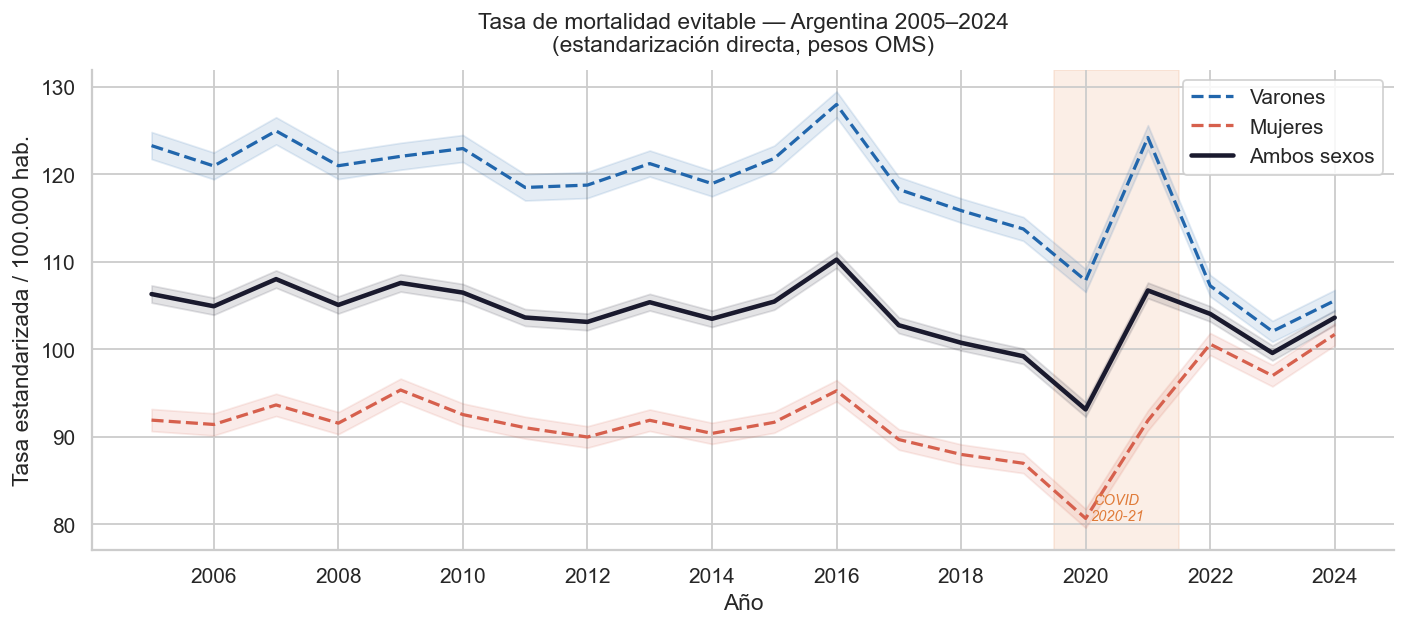

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

for sexo, color, label in [(1, C_MALE, "Varones"), (2, C_FEMALE, "Mujeres"), (0, C_BOTH, "Ambos sexos")]:
    sub = nat[nat["SEXO"] == sexo].sort_values("ANIO")
    lw  = 2.5 if sexo == 0 else 1.8
    ls  = "-" if sexo == 0 else "--"
    ax.plot(sub["ANIO"], sub["TASA_STD"], color=color, lw=lw, ls=ls, label=label, zorder=3)
    ax.fill_between(sub["ANIO"], sub["IC_INF"], sub["IC_SUP"],
                    alpha=0.12, color=color)

# COVID band
ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.12, zorder=0)
ax.text(2020.5, ax.get_ylim()[0] + 3, "COVID\n2020-21",
        ha="center", va="bottom", fontsize=8, color=C_COVID, style="italic")

ax.set_xlabel("Año")
ax.set_ylabel("Tasa estandarizada / 100.000 hab.")
ax.set_title("Tasa de mortalidad evitable — Argentina 2005–2024\n(estandarización directa, pesos OMS)", pad=10)
ax.legend(loc="upper right", framealpha=0.85)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("../output/figures/fig1_serie_nacional.png", bbox_inches="tight")
plt.show()

### 3.3 Ranking provincial — último año disponible (ambos sexos)

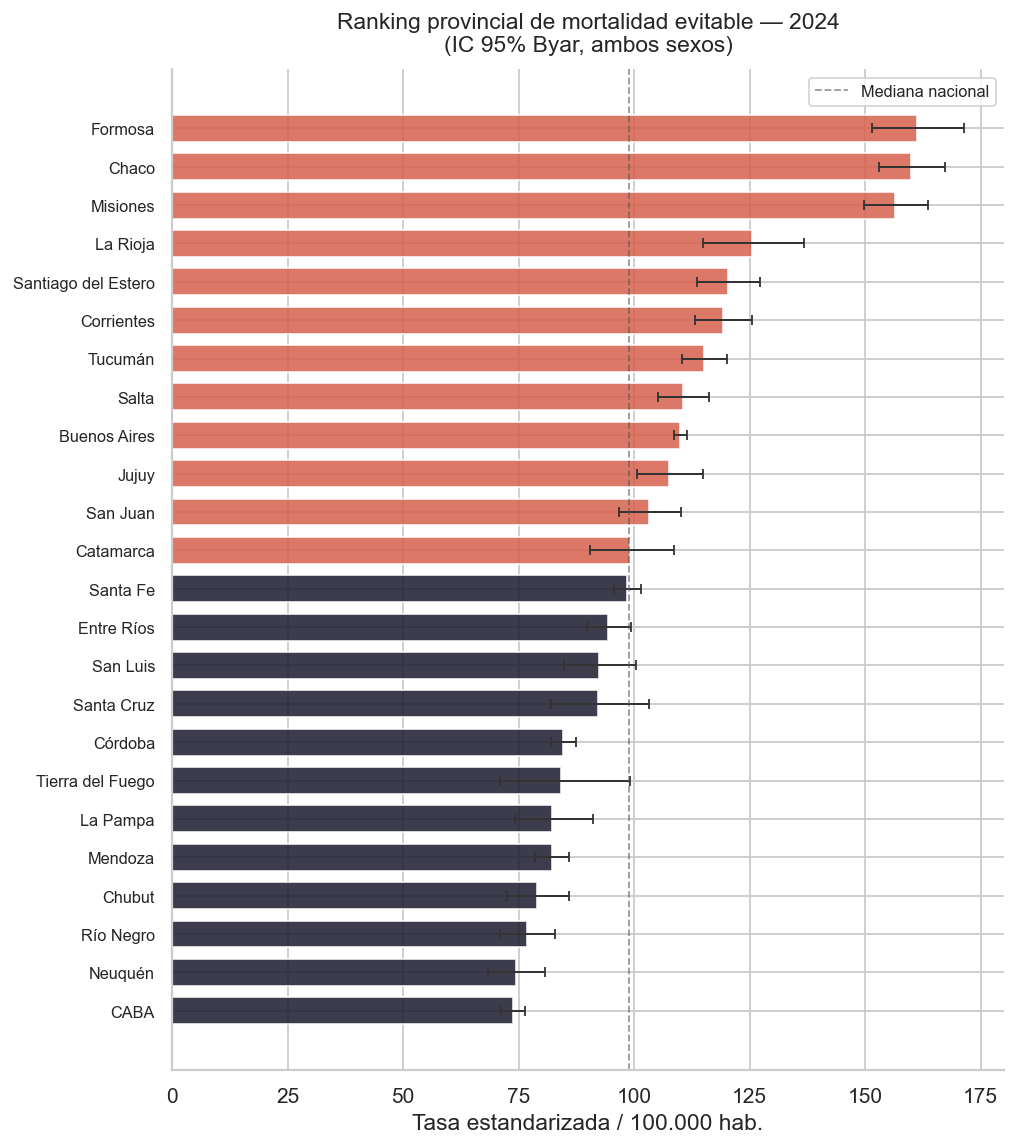

In [4]:
yr = prov["ANIO"].max()
sub = prov[(prov["ANIO"] == yr) & (prov["SEXO"] == 0)].sort_values("TASA_STD")

colors = [C_FEMALE if r > sub["TASA_STD"].median() else C_BOTH for r in sub["TASA_STD"]]

fig, ax = plt.subplots(figsize=(8, 9))
y_pos = range(len(sub))

ax.barh(y_pos, sub["TASA_STD"], color=colors, alpha=0.85, height=0.7)
ax.errorbar(sub["TASA_STD"], y_pos,
            xerr=[sub["TASA_STD"] - sub["IC_INF"], sub["IC_SUP"] - sub["TASA_STD"]],
            fmt="none", color="#333", lw=1.1, capsize=3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(sub["PROV_NOMBRE"].tolist(), fontsize=9)
ax.set_xlabel("Tasa estandarizada / 100.000 hab.")
ax.set_title(f"Ranking provincial de mortalidad evitable — {yr}\n(IC 95% Byar, ambos sexos)", pad=10)
ax.axvline(sub["TASA_STD"].median(), color="#555", lw=1, ls="--", alpha=0.6, label="Mediana nacional")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../output/figures/fig2_ranking_provincial.png", bbox_inches="tight")
plt.show()

### 3.4 Heatmap de tasas provinciales 2005–2024 (ambos sexos)

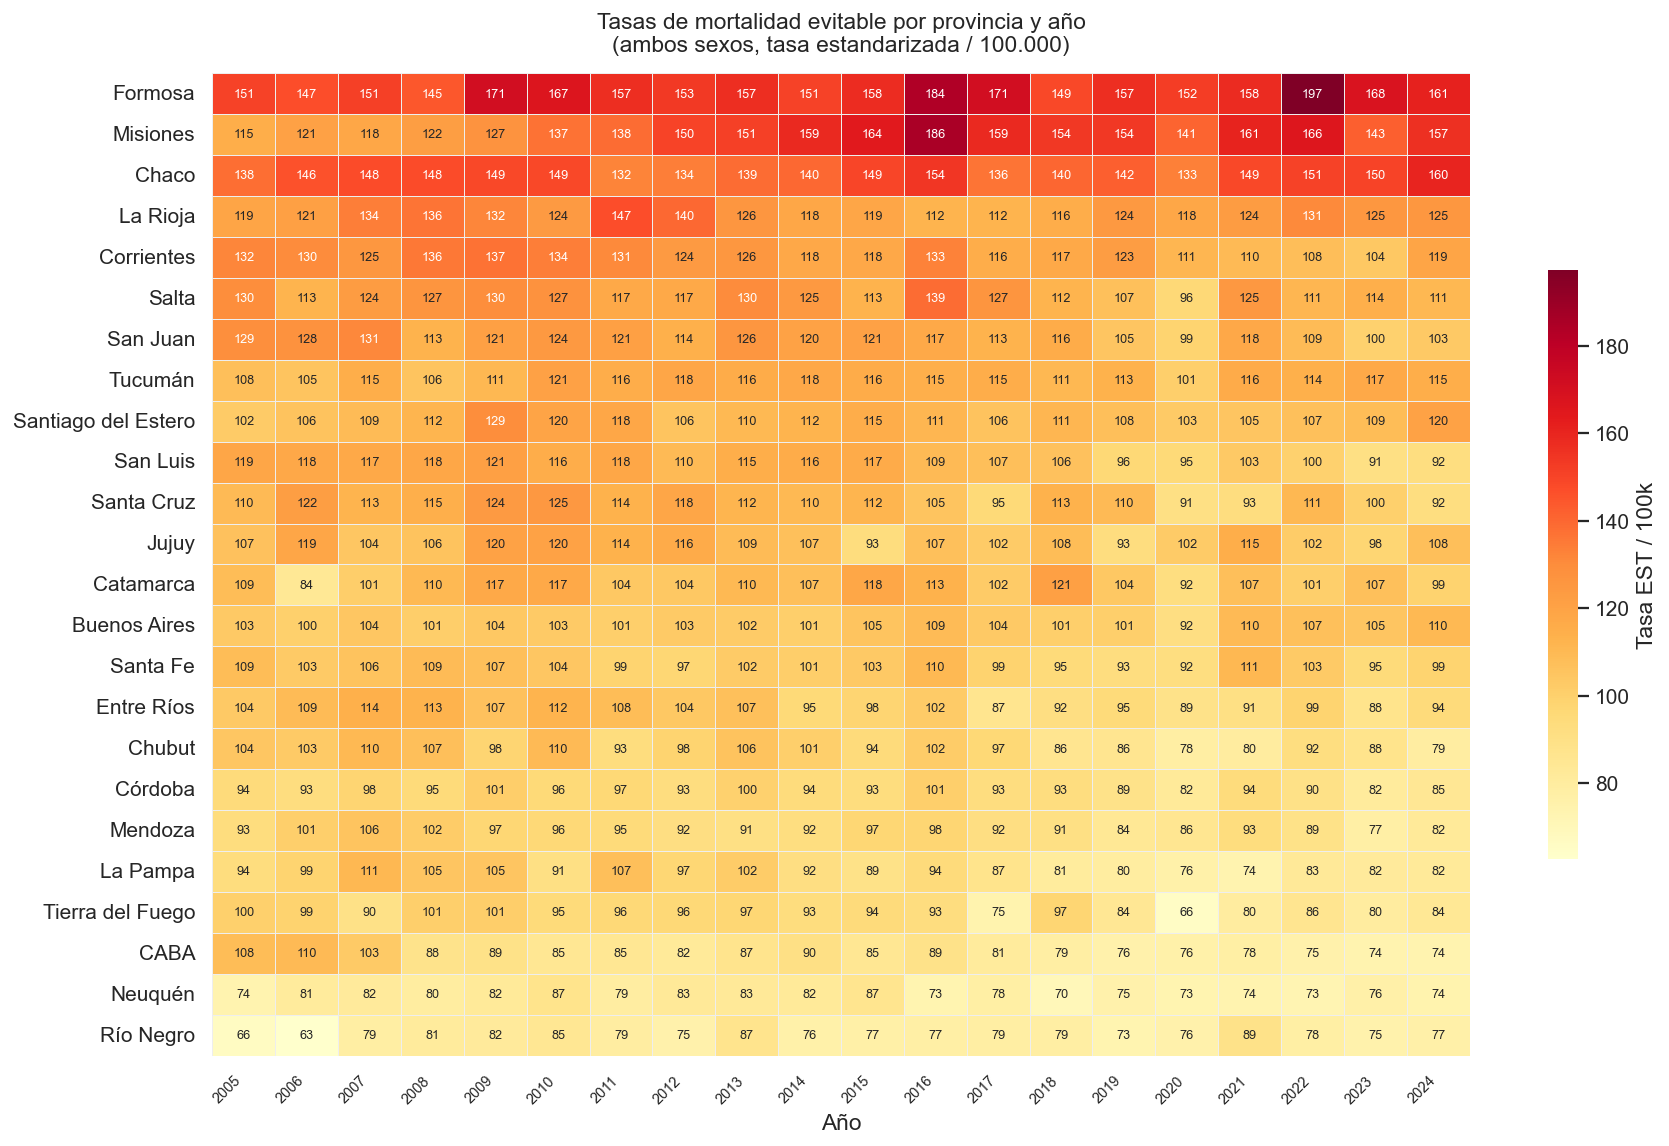

In [5]:
pivot = (prov[prov["SEXO"] == 0]
         .pivot_table(index="PROV_NOMBRE", columns="ANIO", values="TASA_STD"))

# Ordenar provincias por tasa media descendente
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd", linewidths=0.3, linecolor="#eee",
    cbar_kws={"label": "Tasa EST / 100k", "shrink": 0.6},
    fmt=".0f", annot=True, annot_kws={"size": 7},
)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.set_title("Tasas de mortalidad evitable por provincia y año\n(ambos sexos, tasa estandarizada / 100.000)", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../output/figures/fig3_heatmap.png", bbox_inches="tight")
plt.show()

### 3.5 Trayectorias provinciales 2005–2024

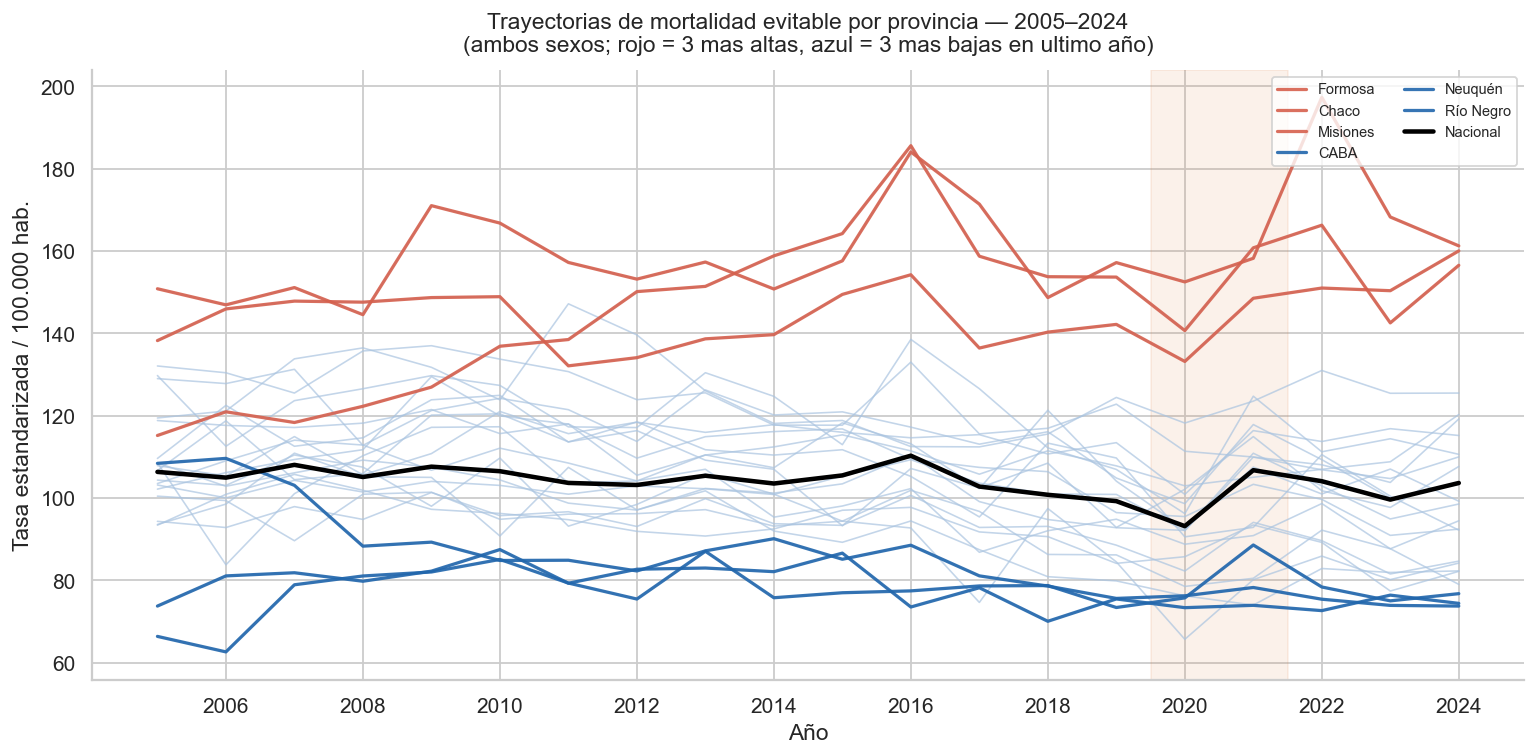

In [6]:
sub = prov[prov["SEXO"] == 0].sort_values("ANIO")

nat_both = nat[nat["SEXO"] == 0].sort_values("ANIO")

fig, ax = plt.subplots(figsize=(12, 6))

for prov_name, grp in sub.groupby("PROV_NOMBRE"):
    ax.plot(grp["ANIO"], grp["TASA_STD"], color="#aac4e0", lw=0.9, alpha=0.7)

# Highlight top and bottom 3 provinces in last year
yr = sub["ANIO"].max()
last = sub[sub["ANIO"] == yr].set_index("PROV_NOMBRE")["TASA_STD"]
top3 = last.nlargest(3).index.tolist()
bot3 = last.nsmallest(3).index.tolist()

for pname in top3:
    grp = sub[sub["PROV_NOMBRE"] == pname]
    ax.plot(grp["ANIO"], grp["TASA_STD"], color=C_FEMALE, lw=1.8, alpha=0.9, label=pname)
for pname in bot3:
    grp = sub[sub["PROV_NOMBRE"] == pname]
    ax.plot(grp["ANIO"], grp["TASA_STD"], color=C_MALE, lw=1.8, alpha=0.9, label=pname)

ax.plot(nat_both["ANIO"], nat_both["TASA_STD"],
        color="black", lw=2.5, ls="-", label="Nacional", zorder=5)

ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.1)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper right", ncol=2)

ax.set_xlabel("Año")
ax.set_ylabel("Tasa estandarizada / 100.000 hab.")
ax.set_title("Trayectorias de mortalidad evitable por provincia — 2005–2024\n(ambos sexos; rojo = 3 mas altas, azul = 3 mas bajas en ultimo año)", pad=10)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig("../output/figures/fig4_spaghetti.png", bbox_inches="tight")
plt.show()

### 3.6 Defunciones evitables por grupo etario — 2005–2024

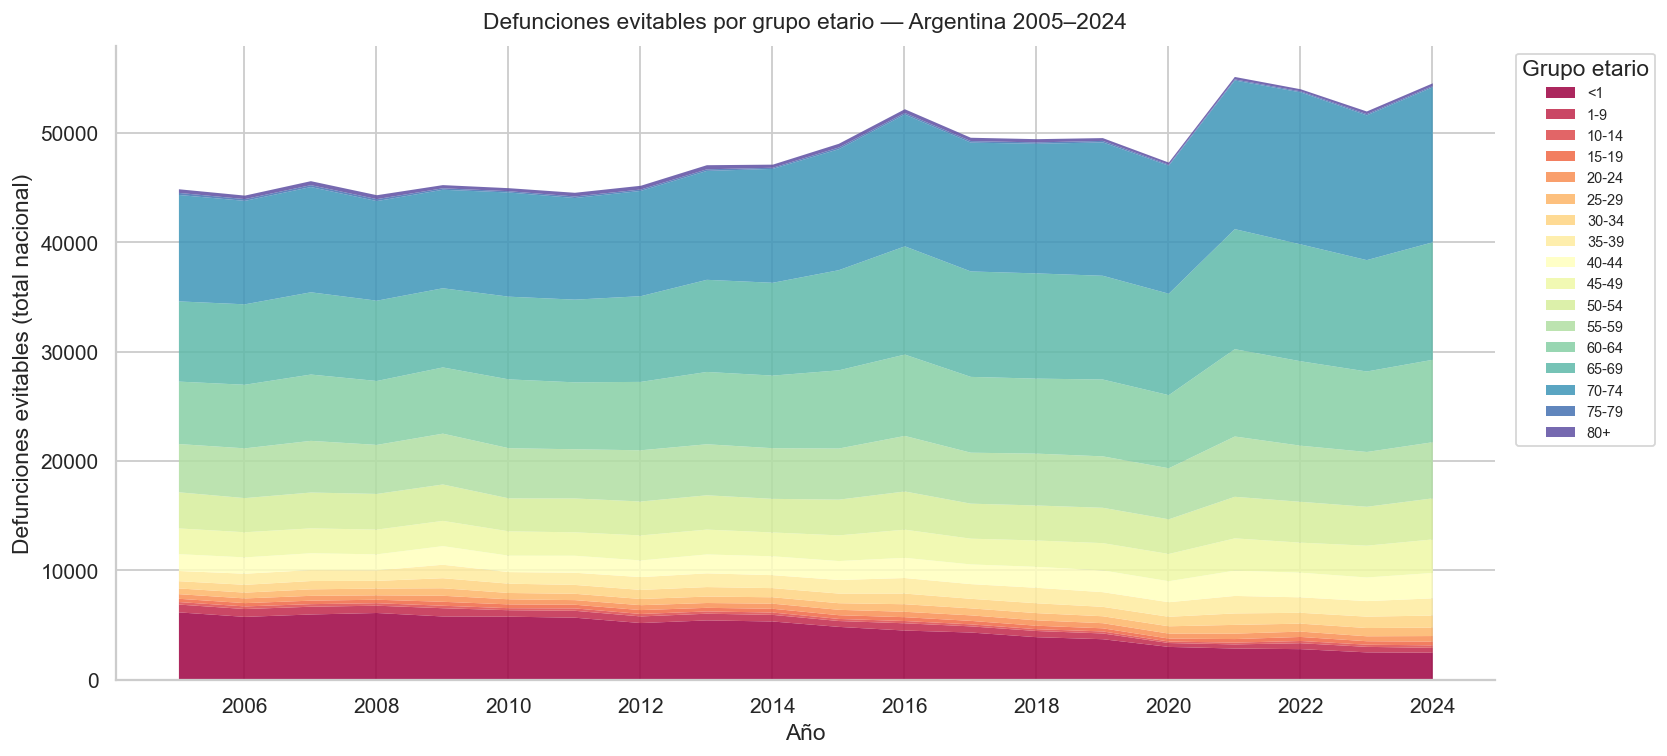

In [7]:
AGE_LABELS = {
    0: "<1", 1: "1-9", 10: "10-14", 15: "15-19", 20: "20-24",
    25: "25-29", 30: "30-34", 35: "35-39", 40: "40-44",
    45: "45-49", 50: "50-54", 55: "55-59", 60: "60-64",
    65: "65-69", 70: "70-74", 75: "75-79", 80: "80+",
}
age["EDAD_LABEL"] = age["EDAD_MIN"].map(AGE_LABELS)

pivot_age = age.pivot_table(index="ANIO", columns="EDAD_LABEL", values="DEF_EVITABLES", aggfunc="sum")
# Ordenar columnas por edad
ordered_cols = [v for k, v in sorted(AGE_LABELS.items()) if v in pivot_age.columns]
pivot_age = pivot_age[ordered_cols]

cmap_age = plt.cm.get_cmap("Spectral", len(ordered_cols))

fig, ax = plt.subplots(figsize=(13, 6))
pivot_age.plot.area(ax=ax, colormap="Spectral", alpha=0.85, linewidth=0)

ax.set_xlabel("Año")
ax.set_ylabel("Defunciones evitables (total nacional)")
ax.set_title("Defunciones evitables por grupo etario — Argentina 2005–2024", pad=10)
ax.legend(title="Grupo etario", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig("../output/figures/fig5_por_edad.png", bbox_inches="tight")
plt.show()

### 3.7 Principales causas de mortalidad evitable — último quinquenio disponible

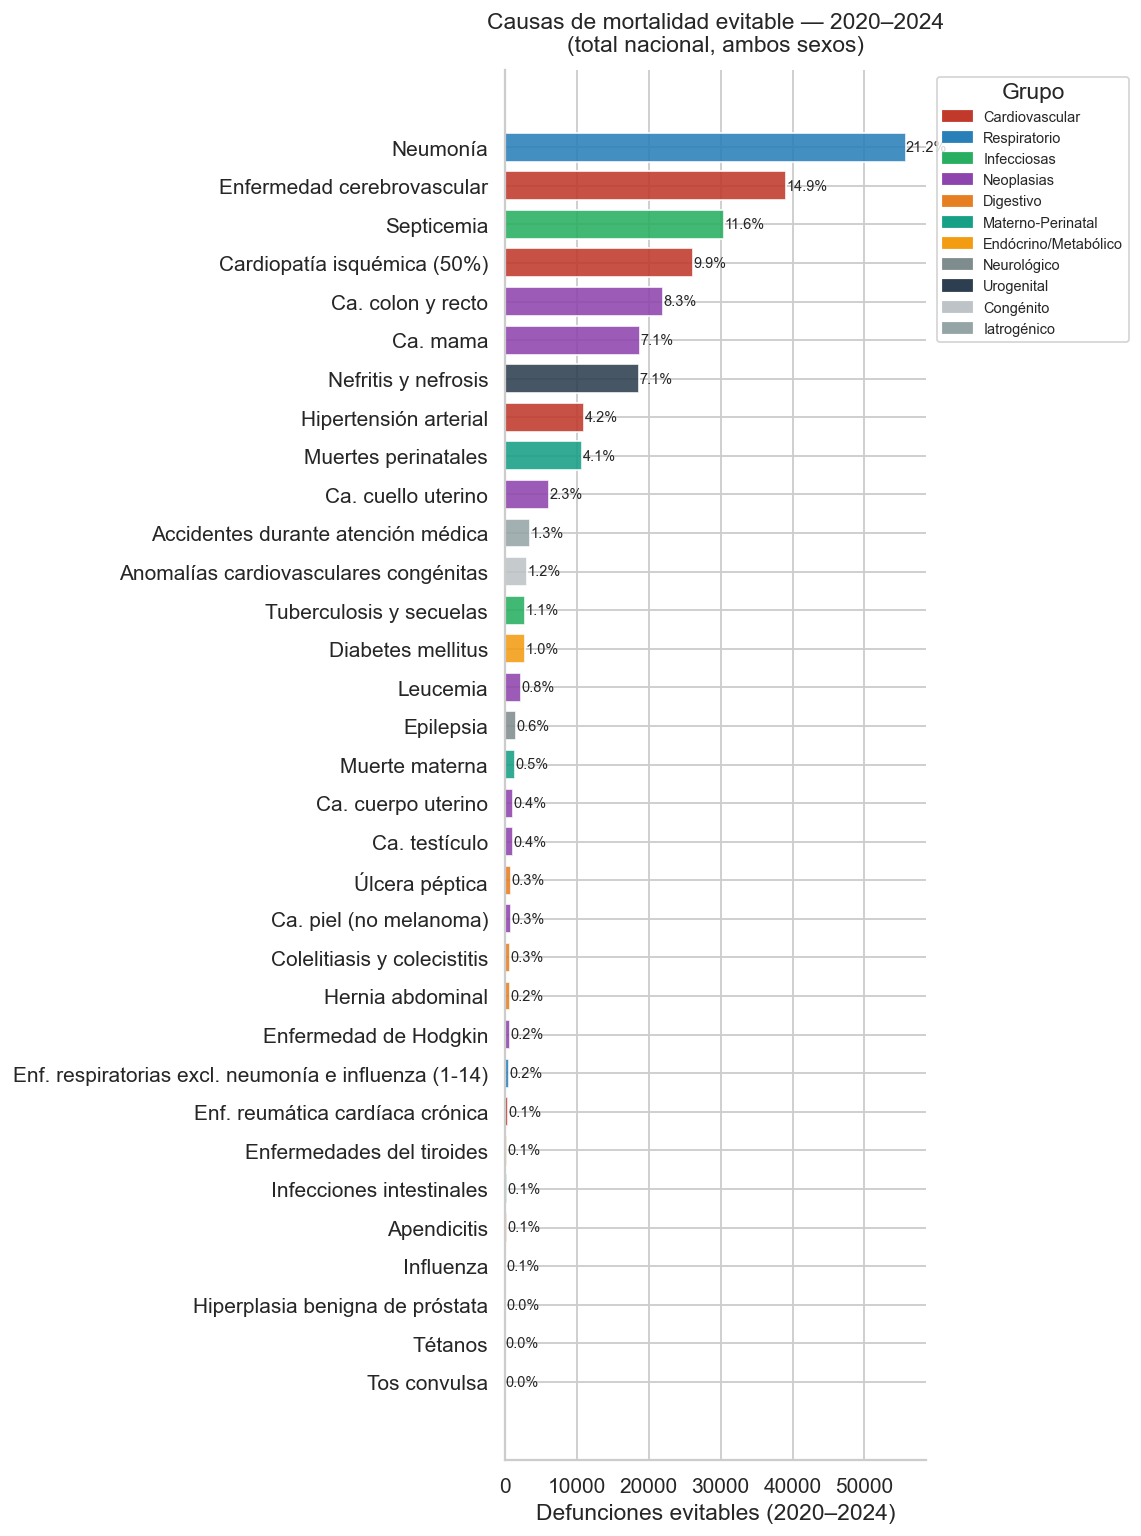

In [8]:
last5_years = sorted(cause["ANIO"].unique())[-5:]
cause5 = cause[cause["ANIO"].isin(last5_years)]

by_cause = (cause5.groupby(["descripcion", "GRUPO"])["DEF_EVITABLES"]
            .sum().reset_index()
            .sort_values("DEF_EVITABLES", ascending=True))

total = by_cause["DEF_EVITABLES"].sum()
by_cause["PCT"] = by_cause["DEF_EVITABLES"] / total * 100

GRUPO_COLORS = {
    "Cardiovascular":       "#c0392b",
    "Respiratorio":         "#2980b9",
    "Infecciosas":          "#27ae60",
    "Neoplasias":           "#8e44ad",
    "Digestivo":            "#e67e22",
    "Materno-Perinatal":    "#16a085",
    "Endócrino/Metabólico": "#f39c12",
    "Neurológico":          "#7f8c8d",
    "Urogenital":           "#2c3e50",
    "Congénito":            "#bdc3c7",
    "Iatrogénico":          "#95a5a6",
    "Otro":                 "#aaa",
}

colors = [GRUPO_COLORS.get(g, "#aaa") for g in by_cause["GRUPO"]]

fig, ax = plt.subplots(figsize=(9, 12))
bars = ax.barh(by_cause["descripcion"], by_cause["DEF_EVITABLES"],
               color=colors, height=0.75, alpha=0.88)

for bar, pct in zip(bars, by_cause["PCT"]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", ha="left", fontsize=8)

patches = [mpatches.Patch(color=v, label=k) for k, v in GRUPO_COLORS.items()
           if k in by_cause["GRUPO"].values]
ax.legend(handles=patches, title="Grupo", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=8)
ax.set_xlabel(f"Defunciones evitables ({last5_years[0]}–{last5_years[-1]})")
ax.set_title(f"Causas de mortalidad evitable — {last5_years[0]}–{last5_years[-1]}\n(total nacional, ambos sexos)", pad=10)
plt.tight_layout()
plt.savefig("../output/figures/fig6_causas.png", bbox_inches="tight")
plt.show()

### 3.8 Tendencia anual de mortalidad evitable por provincia (modelo binomial negativa)

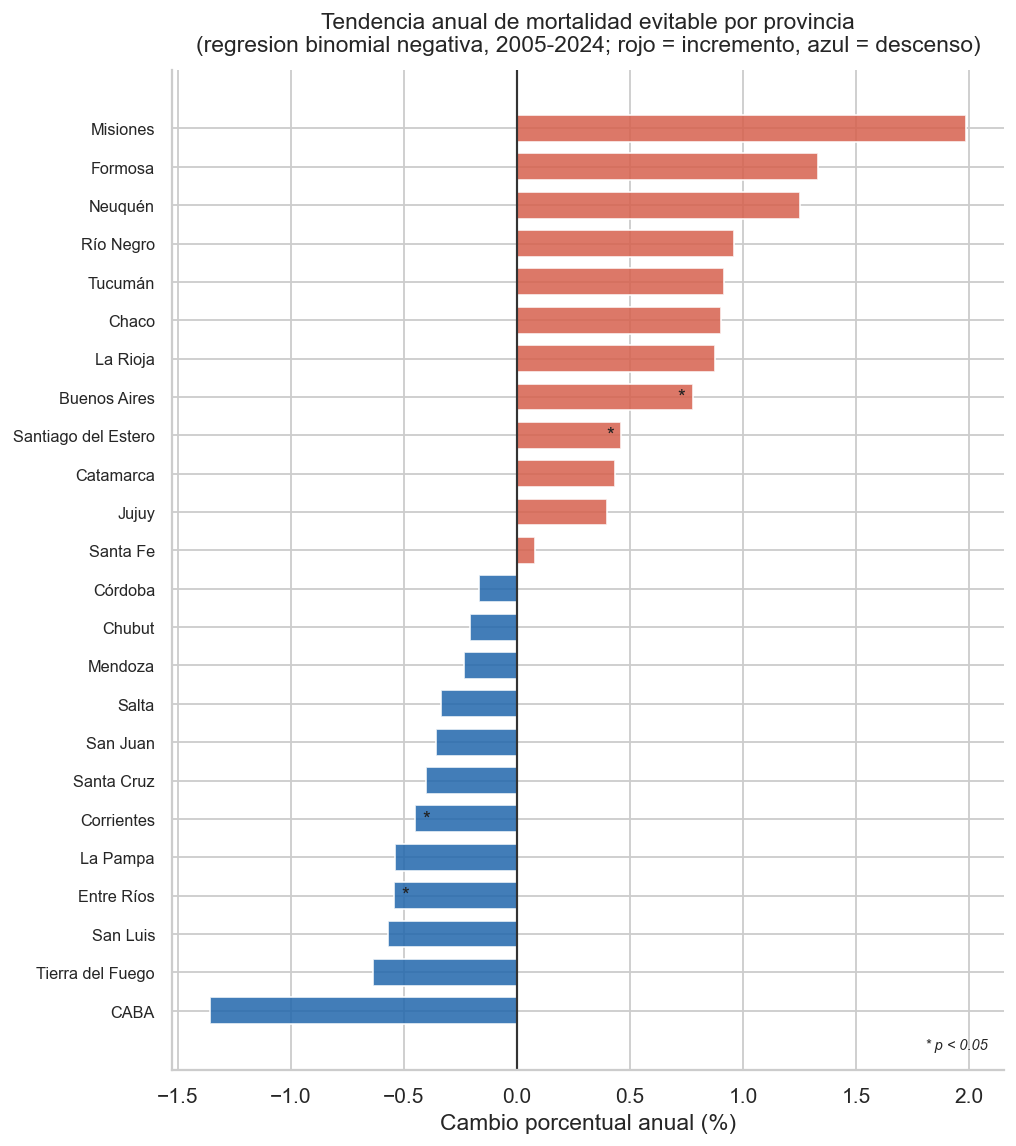

In [9]:
tr = trend.sort_values("cambio_pct_anual")

colors_t = [C_FEMALE if v > 0 else C_MALE for v in tr["cambio_pct_anual"]]

fig, ax = plt.subplots(figsize=(8, 9))
y_pos = range(len(tr))
ax.barh(y_pos, tr["cambio_pct_anual"], color=colors_t, alpha=0.85, height=0.7)

if "ic_inf_pct" in tr.columns and "ic_sup_pct" in tr.columns:
    ax.errorbar(tr["cambio_pct_anual"], y_pos,
                xerr=[tr["cambio_pct_anual"] - tr["ic_inf_pct"],
                      tr["ic_sup_pct"] - tr["cambio_pct_anual"]],
                fmt="none", color="#333", lw=1.1, capsize=3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(tr["PROV_NOMBRE"].tolist(), fontsize=9)
ax.axvline(0, color="#333", lw=1.2)
ax.set_xlabel("Cambio porcentual anual (%)")
ax.set_title("Tendencia anual de mortalidad evitable por provincia\n(regresion binomial negativa, 2005-2024; rojo = incremento, azul = descenso)", pad=10)

sig = tr[tr["p_valor"] < 0.05]
for _, row in sig.iterrows():
    idx = tr.index.get_loc(row.name)
    ax.text(row["cambio_pct_anual"] + (0.05 if row["cambio_pct_anual"] < 0 else -0.05),
            idx, "*", ha="center", va="center", fontsize=11, color="#222")

ax.annotate("* p < 0.05", xy=(0.98, 0.02), xycoords="axes fraction",
            ha="right", fontsize=8, style="italic")
plt.tight_layout()
plt.savefig("../output/figures/fig7_tendencias.png", bbox_inches="tight")
plt.show()

### 3.9 Inequidad interprovincial — Coeficiente de variación 2005–2024

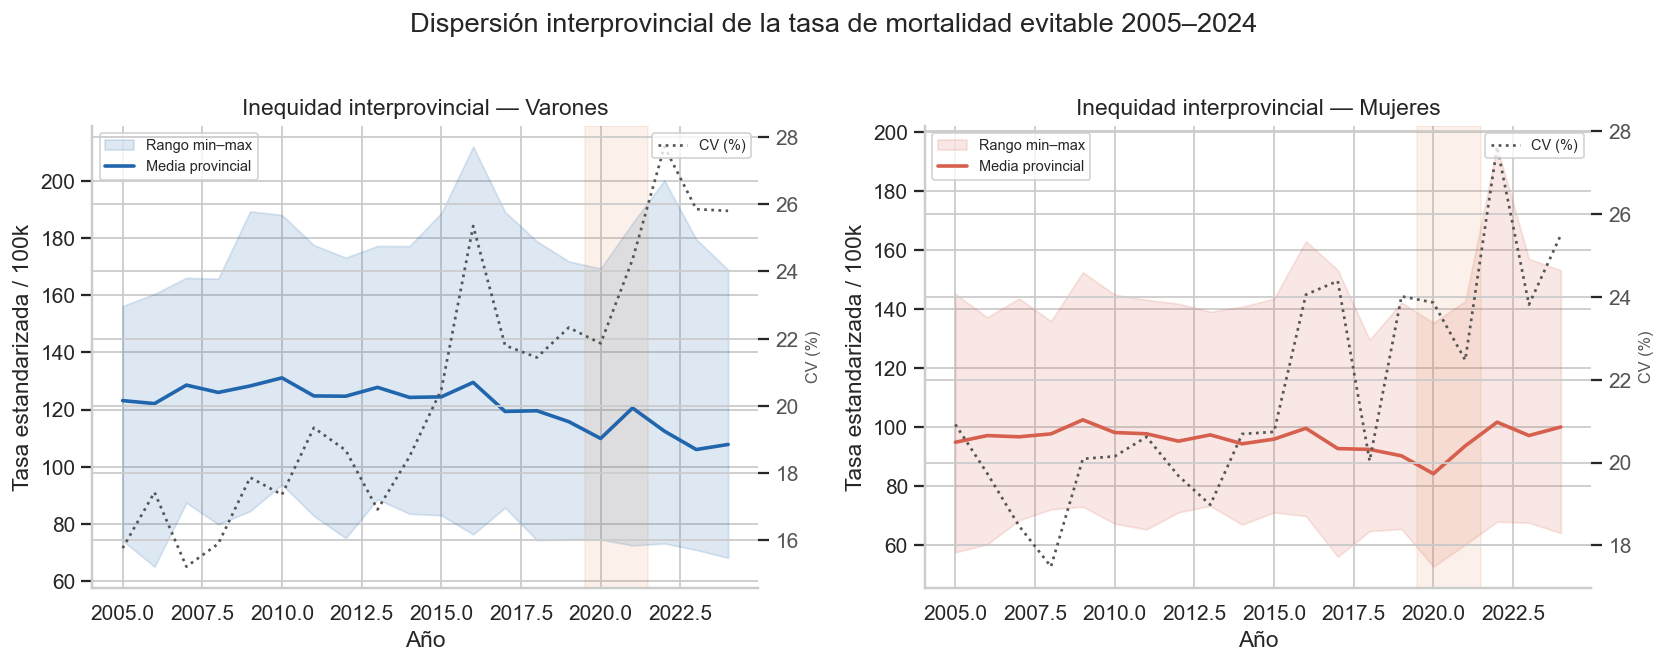

In [10]:
cv_both = cv[cv["SEXO"] != 0]  # ya filtrado, pero por si acaso
cv_m = cv[cv["SEXO"] == 1].sort_values("ANIO")
cv_f = cv[cv["SEXO"] == 2].sort_values("ANIO")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, sub, color, label in [
    (axes[0], cv_m, C_MALE,   "Varones"),
    (axes[1], cv_f, C_FEMALE, "Mujeres"),
]:
    ax.fill_between(sub["ANIO"], sub["TASA_MIN"], sub["TASA_MAX"],
                    alpha=0.15, color=color, label="Rango min–max")
    ax.plot(sub["ANIO"], sub["TASA_MEDIA"], color=color, lw=2, label="Media provincial")
    ax2 = ax.twinx()
    ax2.plot(sub["ANIO"], sub["CV_PCT"], color="#555", lw=1.5, ls=":", label="CV (%)")
    ax2.set_ylabel("CV (%)", color="#555", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#555")

    ax.set_xlabel("Año")
    ax.set_ylabel("Tasa estandarizada / 100k")
    ax.set_title(f"Inequidad interprovincial — {label}")
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)
    ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.1)

plt.suptitle("Dispersión interprovincial de la tasa de mortalidad evitable 2005–2024", y=1.02)
plt.tight_layout()
plt.savefig("../output/figures/fig8_inequidad_cv.png", bbox_inches="tight")
plt.show()

---
## 4. Tablas resumen

### Tabla 1 — Serie temporal nacional (ambos sexos)

In [11]:
t1 = (nat[nat["SEXO"] == 0][["ANIO","TASA_STD","IC_INF","IC_SUP","DEF_EVITABLES","POB_TOTAL"]]
      .rename(columns={"ANIO":"Año","TASA_STD":"Tasa EST","IC_INF":"IC inf 95%",
                       "IC_SUP":"IC sup 95%","DEF_EVITABLES":"Def. evitables",
                       "POB_TOTAL":"Población"})
      .sort_values("Año")
      .reset_index(drop=True))
t1["Tasa EST"]   = t1["Tasa EST"].round(1)
t1["IC inf 95%"] = t1["IC inf 95%"].round(1)
t1["IC sup 95%"] = t1["IC sup 95%"].round(1)
t1["Def. evitables"] = t1["Def. evitables"].round(0).astype(int)
t1["Población"] = t1["Población"].astype(int)
t1

,Año,Tasa EST,IC inf 95%,IC sup 95%,Def. evitables,Población
0,2005,106.3,105.3,107.3,44900,40788453
1,2006,104.9,104.0,105.9,44320,40788453
2,2007,108.0,107.0,109.0,45640,40788453
3,2008,105.1,104.1,106.1,44355,40788453
4,2009,107.6,106.6,108.6,45280,40788453
5,2010,106.5,105.5,107.5,44998,40788453
6,2011,103.6,102.7,104.6,44578,41261490
7,2012,103.1,102.2,104.1,45220,41733271
8,2013,105.4,104.4,106.4,47100,42202935
9,2014,103.5,102.6,104.4,47152,42669500


### Tabla 2 — Ranking provincial último año (ambos sexos)

In [12]:
yr = prov["ANIO"].max()
t2 = (prov[(prov["ANIO"] == yr) & (prov["SEXO"] == 0)]
      [["PROV_NOMBRE","TASA_STD","IC_INF","IC_SUP","DEF_EVITABLES"]]
      .rename(columns={"PROV_NOMBRE":"Provincia","TASA_STD":"Tasa EST",
                       "IC_INF":"IC inf 95%","IC_SUP":"IC sup 95%",
                       "DEF_EVITABLES":"Def. evitables"})
      .sort_values("Tasa EST")
      .reset_index(drop=True))
t2.index = t2.index + 1
t2["Tasa EST"]   = t2["Tasa EST"].round(1)
t2["IC inf 95%"] = t2["IC inf 95%"].round(1)
t2["IC sup 95%"] = t2["IC sup 95%"].round(1)
t2["Def. evitables"] = t2["Def. evitables"].round(0).astype(int)
t2

,Provincia,Tasa EST,IC inf 95%,IC sup 95%,Def. evitables
1,CABA,73.7,71.1,76.4,3050
2,Neuquén,74.4,68.3,80.8,560
3,Río Negro,76.7,71.0,82.8,656
4,Chubut,79.0,72.4,86.0,532
5,Mendoza,82.2,78.5,85.9,1920
6,La Pampa,82.3,74.2,91.0,376
7,Tierra del Fuego,84.2,71.0,99.0,145
8,Córdoba,84.6,82.0,87.3,3932
9,Santa Cruz,92.2,81.9,103.3,294
10,San Luis,92.4,84.9,100.4,560


### Tabla 3 — Tendencia anual por provincia

In [13]:
t3 = (trend[["PROV_NOMBRE","cambio_pct_anual","p_valor","converged"]]
      .rename(columns={"PROV_NOMBRE":"Provincia",
                       "cambio_pct_anual":"Cambio % anual",
                       "p_valor":"p-valor",
                       "converged":"NB converge"})
      .sort_values("Cambio % anual")
      .reset_index(drop=True))
t3["Cambio % anual"] = t3["Cambio % anual"].round(2)
t3["p-valor"] = t3["p-valor"].round(4)
t3

,Provincia,Cambio % anual,p-valor,NB converge
0,CABA,-1.36,NaN,True
1,Tierra del Fuego,-0.64,NaN,True
2,San Luis,-0.57,NaN,True
3,Entre Ríos,-0.54,0.0018,True
4,La Pampa,-0.54,NaN,True
5,Corrientes,-0.45,0.0050,True
6,Santa Cruz,-0.40,NaN,True
7,San Juan,-0.36,0.0576,True
8,Salta,-0.33,0.2201,True
9,Mendoza,-0.24,NaN,True


### Tabla 4 — Top 10 causas, último quinquenio

In [14]:
last5_years = sorted(cause["ANIO"].unique())[-5:]
t4 = (cause[cause["ANIO"].isin(last5_years)]
      .groupby(["GRUPO","descripcion"])["DEF_EVITABLES"]
      .sum().reset_index()
      .sort_values("DEF_EVITABLES", ascending=False)
      .head(10)
      .reset_index(drop=True))
total = t4["DEF_EVITABLES"].sum()
t4["%"] = (t4["DEF_EVITABLES"] / cause[cause["ANIO"].isin(last5_years)]["DEF_EVITABLES"].sum() * 100).round(1)
t4.index = t4.index + 1
t4.rename(columns={"GRUPO":"Grupo","descripcion":"Causa","DEF_EVITABLES":"Def. evitables"})

,Grupo,Causa,Def. evitables,%
1,Respiratorio,Neumonía,55736.0,21.2
2,Cardiovascular,Enfermedad cerebrovascular,39141.0,14.9
3,Infecciosas,Septicemia,30410.0,11.6
4,Cardiovascular,Cardiopatía isquémica (50%),26158.0,9.9
5,Neoplasias,Ca. colon y recto,21928.0,8.3
6,Neoplasias,Ca. mama,18810.0,7.1
7,Urogenital,Nefritis y nefrosis,18676.0,7.1
8,Cardiovascular,Hipertensión arterial,10998.0,4.2
9,Materno-Perinatal,Muertes perinatales,10708.0,4.1
10,Neoplasias,Ca. cuello uterino,6080.0,2.3


---
## 5. Discusión

### 5.1 Tendencia general

La tasa de mortalidad evitable nacional presentó una **leve tendencia decreciente** a lo largo del período 2005–2024, con una reducción acumulada de aproximadamente 2% en términos relativos. Este descenso —aunque modesto— es consistente con mejoras en la cobertura de atención primaria, ampliación de programas de tratamiento crónico (cardio-metabolismo, oncología) y mayor acceso a medicamentos esenciales.

El **pico observado alrededor de 2016** merece análisis adicional: coincide con un período de ajustes en el gasto en salud y potencial deterioro del acceso en algunas jurisdicciones, aunque la causalidad requiere estudios de mayor resolución.

El **mínimo de 2020** no debe interpretarse como una mejora real del sistema de salud. Durante la pandemia COVID-19, la saturación del sistema, el subregistro de causas y la muerte fuera del ámbito hospitalario distorsionaron la clasificación de causas evitables. Los años 2020–2021 deben considerarse con cautela metodológica.

### 5.2 Brecha por sexo

La tasa masculina fue consistentemente 35–40% más alta que la femenina a lo largo de todo el período. Esta brecha refleja tanto una mayor exposición masculina a factores de riesgo (tabaquismo, consumo de alcohol, dieta) como diferencias en el uso de los servicios de salud. Que la brecha sea estable —sin convergencia notable— sugiere que las intervenciones del período no abordaron diferencialmente el riesgo en varones.

### 5.3 Inequidad interprovincial

La razón entre la tasa máxima y mínima provincial supera **3x en el último año**, lo que indica una inequidad sustancial y persistente. El coeficiente de variación interprovincial no muestra una tendencia clara al descenso, lo que sugiere que las mejoras nacionales no han reducido la heterogeneidad territorial.

Las provincias del NOA y NEA (Formosa, Chaco, Misiones, Jujuy, Santiago del Estero) sistemáticamente presentan las tasas más altas, consistente con menor cobertura de atención médica, mayor proporción de población rural y menor ingreso per cápita provincial. CABA, Santa Fe y Córdoba muestran las tasas más bajas, reflejo de mayor densidad de recursos de salud.

### 5.4 Causas dominantes

La patología **cerebrovascular** y la **cardiopatía isquémica** (al 50%) concentran conjuntamente ~27% de la MA total. Estas causas son sensibles al control de hipertensión, dislipemia, tabaquismo y diabetes, lo que apunta a que el fortalecimiento de la atención primaria con foco en enfermedades crónicas tendría el mayor impacto potencial.

La **neumonía** representa ~16% de la carga, proporcional especialmente a grupos vulnerables (adultos mayores, infancias con comorbilidades). La alta proporción de causas cardiovasculares y respiratorias en adultos mayores (60+) es coherente con la estructura epidemiológica de un país de transición avanzada.

### 5.5 Comparación regional

Las tasas argentinas (~100–110/100k) son comparables a países latinoamericanos de ingreso medio-alto, pero superiores a las de Europa Occidental (~80–90/100k). La heterogeneidad interprovincial argentina es análoga a la observada entre países de diferente nivel de desarrollo, lo que subraya la importancia de intervenciones territorialmente focalizadas.

---
## 6. Limitaciones

| Limitación | Impacto potencial | Mitigación |
|------------|-------------------|------------|
| **Años 2005–2009:** población aproximada con valor 2010 | Subestimación/sobreestimación leve de tasas en ese período | Documentado; análisis de tendencia robusto a errores sistemáticos si son constantes |
| **Ausencia de ajuste por factores de riesgo** | Parte de la variación interprovincial refleja diferencias en prevalencia de tabaquismo, obesidad, etc. | Requeriría integración con ENFR provincial |
| **Subregistro de causas (códigos R)** | Tasas subestimadas donde el % de R-codes es alto (ver quality_report.csv) | Monitoreo por año/provincia; interpretación cautelosa en jurisdicciones con >20% R-codes |
| **Cambio de formato GRUPEDAD en 2024** | Grupos etarios 1-4 no distinguibles de 5-9 en 2024 | Ambos colapsados al grupo canónico 1-9; impacto mínimo en adultos |
| **Distorsión COVID 2020–2021** | Mal-clasificación de causas, subregistro extra-hospitalario | Señalizado visualmente en gráficos; análisis de tendencia disponible excluyendo esos años |
| **Solo mortalidad** | No captura morbilidad ni discapacidad asociadas | El indicador es la MA por definición; para carga de enfermedad requeriría AVAD |
| **Fracción 50% cardiopatía isquémica** | Depende de la evidencia subyacente del corte temporal (2003) | Sensibilidad no presentada; puede recalcularse modificando el parámetro `fraccion` |

---
## Referencias

1. Nolte E, McKee M. *Measuring the health of nations: analysis of mortality amenable to health care.* BMJ 2003;327:1129. doi:10.1136/bmj.327.7424.1129

2. Ahmad OB, Boschi-Pinto C, Lopez AD, et al. *Age standardization of rates: a new WHO standard.* GPE Discussion Paper Series No. 31. WHO 2001.

3. Breslow NE, Day NE. *Statistical Methods in Cancer Research, Vol. II. The Design and Analysis of Cohort Studies.* IARC Scientific Publications No. 82. Lyon: IARC, 1987. (Byar approximation, pp. 65-66)

4. Rutstein DD, Berenberg W, Chalmers TC, et al. *Measuring the quality of medical care.* N Engl J Med 1976;294:582–588.

5. DEIS — Dirección de Estadísticas e Información de Salud, Ministerio de Salud de la Nación Argentina. *Estadísticas vitales: información básica.* Disponible en: http://www.deis.msal.gov.ar

6. INDEC — Instituto Nacional de Estadística y Censos. *Estimaciones y proyecciones de población 2010–2040. Total del país.* Serie Análisis Demográfico 36. Buenos Aires: INDEC, 2013.

7. Nolte E, McKee M. *Variations in amenable mortality — trends in 16 high-income nations.* Health Policy 2011;103:47–52.

8. Kamarudeen S. *Amenable mortality as an indicator of healthcare quality: a review.* Office for National Statistics Methods Series. Newport: ONS, 2010.

---
*Análisis realizado con Python 3.10+. Código fuente disponible en: [github.com](https://github.com)*
*Datos: DEIS, Ministerio de Salud de la Nación Argentina · INDEC*